# Tutorial 100: Unconditional Flow Matching on Synthetic Data

Flow matching trains a neural network to push one population of cells to another
by learning a **velocity field** which tells each cell which direction to move at each point in time.


* __Data__: Two-Moons data
* __Task__: Transport cells from bottom moon -> top moon

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Contents

1. **Section 1**: Inline Components
2. **Section 2**: Data Creation
3. **Section 3**: DataManager Setup
4. **Section 4**: Training Batcher Setup
5. **Section 5**: Model Setup
6. **Section 6**: Training
7. **Section 7**: Inference
8. **Section 8**: ODE Trajectories

In [16]:
import types
import numpy as np
import torch
import matplotlib.pyplot as plt

from sc_flow.trainer._trainer import FlowTrainer
from sc_flow.backends.torch.nn import MLPUnconditionalVF
from sc_flow.backends.torch.coupling import independent_coupling
from sc_flow.backends.torch.probability_paths import LinearGaussianProbabilityPath

# This is in the ODESolver scirpt from sc_flow.backends.jax._types import TVfFn
# This is a problem because it is JAX but the backnd is Torch
# So if user only wants to use torch, they still need to download JAX for this to work
# Well I have roblem downloading JAX so for my convenience
# Commented out for now
from sc_flow.backends.torch.solvers import ODESolver
from sc_flow import methods as basemethods
from sc_flow.dataset.toy_data import get_toy_dataset
from sc_flow.data import DataManager, MatchedData
from sc_flow.data.samplers import FTrainSampler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## Section 1: Inline Components

`BaseMethod` is defined inline because this branch does not have it. This section will be removed later and everything else will bechanged accordingly.

In [17]:
class BaseMethod(basemethods.FlowMatching):
    """Minimal flow matching implementation used in this tutorial."""

    def __init__(self, vf, probability_path, time_sampler, solver, match_fn, opt=None, **kwargs):
        self.vf = vf
        self.probability_path = probability_path
        self.time_sampler = time_sampler
        self.match_fn = match_fn
        self.solver = solver
        self.opt = opt(self.vf.parameters(), lr=5e-4)
        self._is_trained = False
        self.vf_step_fn = self._get_vf_step_fn()

    def _get_vf_step_fn(self):
        def vf_step_fn(time, source, target):
            def loss_fn(t, src, tgt):
                x_t = self.probability_path.compute_xt(t, src, tgt)
                v_t = self.vf(t, x_t)
                u_t = self.probability_path.compute_ut(t, x_t, src, tgt)
                return torch.mean((v_t - u_t) ** 2)

            self.opt.zero_grad()
            loss = loss_fn(time, source, target)
            loss.backward()
            self.opt.step()
            return loss

        return vf_step_fn

    def step_fn(self, batch):
        """Compute one training step and return the loss tensor."""
        source = batch["src_cell_data"]
        target = batch["tgt_cell_data"]
        time = self.time_sampler(source.shape[0])
        src_ixs, tgt_ixs = self.match_fn(source, target)
        return self.vf_step_fn(time, source[src_ixs], target[tgt_ixs])

    def train_step(self, batch, prng_key=None):
        """Run one gradient step and return the scalar loss."""
        return float(self.step_fn(batch).cpu())

    def predict(self, x, condition=None, **kwargs):
        """Integrate ODE from t=0 to t=1 and return predicted cells."""
        time = torch.linspace(0.0, 1.0, 101)
        return self.solver.solve(x, time, rtol=1e-6, atol=1e-7)

    def predict_trajectory(self, x, n_steps: int = 20):
        """Returns the full ODE trajectory, shape (n_steps, n_cells, n_dims)."""
        time = torch.linspace(0.0, 1.0, n_steps)
        return self.solver.solve(x, time, rtol=1e-5, atol=1e-6, return_trajectory=True)


def uniform_time_sampler(n: int) -> torch.Tensor:
    """Sample n uniform random times in [0, 1]."""
    return torch.rand(size=(n,))

## Section 2: Data Creation

We create synthetic two-moons data using `get_toy_dataset`. Check out [300_Toy_Datasets](../examples/data/300_toy_datasets.ipynb) for all possible datasets that can be created.

In [18]:
dataset = get_toy_dataset("moons", n_samples=10_000, noise=0.1, random_state=SEED)
adata = dataset.adata

# Labels are in obsm['Y'] as strings ('0' / '1') — move to obs for DataManager
adata.obs["label"] = np.array(adata.obsm["Y"]).ravel()

# Dummy condition representation — required by DataManager schema, ignored by dispatch_fn
adata.uns["label_reps"] = {"0": np.zeros(1, dtype=np.float32), "1": np.zeros(1, dtype=np.float32)}

print(adata)
print("\nLabel counts:")
print(adata.obs["label"].value_counts())

AnnData object with n_obs × n_vars = 10000 × 2
    obs: 'label'
    uns: 'dataset_info', 'label_reps'
    obsm: 'Y'

Label counts:
label
1    5000
0    5000
Name: count, dtype: int64


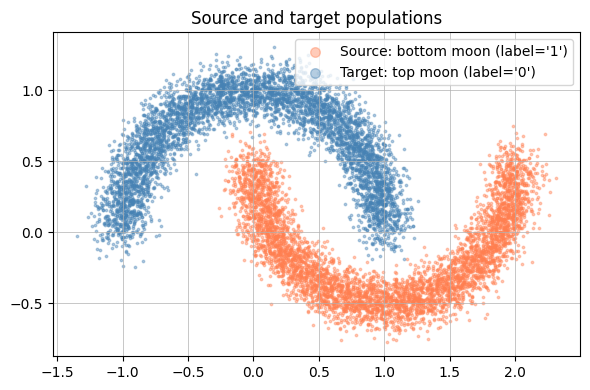

In [19]:
X = np.array(adata.X)
labels = adata.obs["label"].values

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    X[labels == "1", 0], X[labels == "1", 1], s=3, alpha=0.4, color="coral", label="Source: bottom moon (label='1')"
)
ax.scatter(
    X[labels == "0", 0], X[labels == "0", 1], s=3, alpha=0.4, color="steelblue", label="Target: top moon (label='0')"
)
ax.set_title("Source and target populations")
ax.legend(markerscale=4)
ax.grid(linewidth=0.5)
plt.tight_layout()
plt.show()

## Section 3: DataManager Setup

Check out [100_DataManager](../examples/data/100_datamanager.ipynb) to see how `DataManager` can be used and [110_DataManager_Internals](../examples/data/100_datamanager_internals.ipynb) to understand how it works

In [20]:
manager = DataManager(
    sample_rep=None,  # adata.X used by default
    conditions={"moon": ["label"]},  # split by the 'label' obs column
    conditions_reps={"moon": "label_reps"},  # dummy — not used by dispatch_fn, but to keep schema consistent
    control_values_dict={"moon": "1"},  # label '1' (bottom moon) is the source
)
nested_data = manager.compile_adata(adata)

inner = nested_data[()]
ex = inner[("0",)]
print(f"Source cells (bottom moon): {ex.n_src_obs}")
print(f"Target cells (top moon):    {ex.n_tgt_obs}")

100%|██████████| 1/1 [00:00<00:00, 122.27it/s]

Source cells (bottom moon): 5000
Target cells (top moon):    5000


## Section 4: Training Batcher Setup

The `dispatch_fn` converts a `MatchedData` object into the training dict.
For the unconditional model we return only `src_cell_data` and `tgt_cell_data` — no `condition` key.

`There is some problems with the API (?). have to checkthis again, but this is a workaound for now.`

In [21]:
def dispatch_fn(matched: MatchedData) -> dict:
    """Convert a MatchedData sample into a training batch dict."""
    src = matched.source_distribution.state_data.X.astype(np.float32)
    tgt = matched.target_distribution.state_data.X.astype(np.float32)
    return {
        "src_cell_data": torch.tensor(src, dtype=torch.float32),
        "tgt_cell_data": torch.tensor(tgt, dtype=torch.float32),
        # No 'condition' key — unconditional model
    }


BATCH_SIZE = 512
_inner_sampler = FTrainSampler(
    nested_data,
    dispatch_fn,
    batch_size=BATCH_SIZE,
    n_nodes=1,
    replace_samples=True,
)
# FTrainSampler.sample() returns tuple[dict]; FlowTrainer expects a plain dict
train_loader = types.SimpleNamespace(sample=lambda _=None: _inner_sampler.sample()[0])

batch = train_loader.sample()
print("src_cell_data:", batch["src_cell_data"].shape)
print("tgt_cell_data:", batch["tgt_cell_data"].shape)

src_cell_data: torch.Size([512, 2])
tgt_cell_data: torch.Size([512, 2])


## Section 5: Model Setup

In [23]:
# Velocity Field
vf = MLPUnconditionalVF(
    state_dim=2,
    encode_state=True,
    encode_time=True,
    time_features_id="torch-cfm",
    state_encoder_mlp_kwargs={"hidden_dims": (32,)},
    time_encoder_mlp_kwargs={"hidden_dims": (16,)},
    vf_decoder_mlp_kwargs={"hidden_dims": (64, 64)},
)

# ODESolver takes the velocity field at construction and creates the integration closure
solver = ODESolver(dynamics=vf, method="euler", vf_kwargs={"condition_dict": None})

g = torch.Generator()
g.manual_seed(42)
model = BaseMethod(
    vf=vf,
    probability_path=LinearGaussianProbabilityPath(sigma=0.01, prng=g),
    time_sampler=uniform_time_sampler,
    solver=solver,
    match_fn=independent_coupling,
    opt=torch.optim.AdamW,
)
trainer = FlowTrainer(method=model, require_prng=False)
print("Model ready.")

Model ready.


## Section 6: Training

In [24]:
trainer.fit(train_dataloader=train_loader, num_iterations=5_000, valid_freq=5_001)

100%|██████████| 5000/5000 [01:13<00:00, 67.76it/s] 


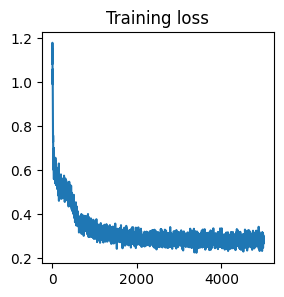

In [25]:
trainer.plot_training_logs()
plt.title("Training loss")
plt.show()

## Section 7: Inference

We take source cells from `nested_data` and integrate the ODE from t=0 to t=1.
The predicted positions should match the shape of the target cells.

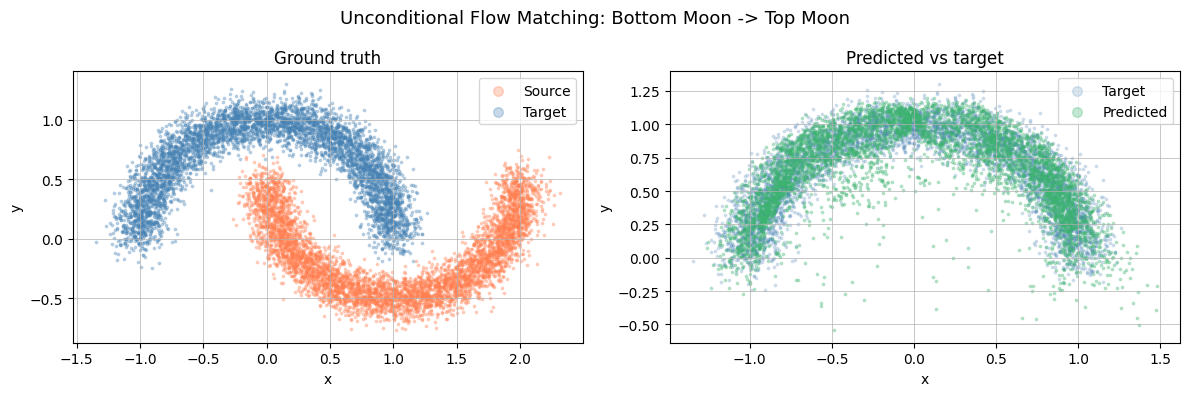

In [26]:
matched = nested_data[()][("0",)]
src_np = matched.source_distribution.state_data.X.astype(np.float32)
tgt_np = matched.target_distribution.state_data.X.astype(np.float32)
src_t = torch.tensor(src_np)

model.vf.eval()
with torch.no_grad():
    predicted = model.predict(src_t)

pred_np = predicted.numpy()

# idx used here and reused in Section 8 for the same cells
n_show = 30
step = max(1, len(src_np) // n_show)
idx = np.arange(0, len(src_np), step)[:n_show]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(src_np[:, 0], src_np[:, 1], s=3, alpha=0.3, color="coral", label="Source")
axes[0].scatter(tgt_np[:, 0], tgt_np[:, 1], s=3, alpha=0.3, color="steelblue", label="Target")
axes[0].set_title("Ground truth")
axes[0].legend(markerscale=4)
axes[0].grid(linewidth=0.5)

axes[1].scatter(tgt_np[:, 0], tgt_np[:, 1], s=3, alpha=0.2, color="steelblue", label="Target")
axes[1].scatter(pred_np[:, 0], pred_np[:, 1], s=3, alpha=0.3, color="mediumseagreen", label="Predicted")
axes[1].set_title("Predicted vs target")
axes[1].legend(markerscale=4)
axes[1].grid(linewidth=0.5)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Unconditional Flow Matching: Bottom Moon -> Top Moon", fontsize=13)
plt.tight_layout()
plt.show()

## Section 8: ODE Trajectories

Each cell follows a smooth path from t=0 to t=1. Trajectories that go broadly in the
same direction (without crossing) indicate the model has learned a coherent velocity field.

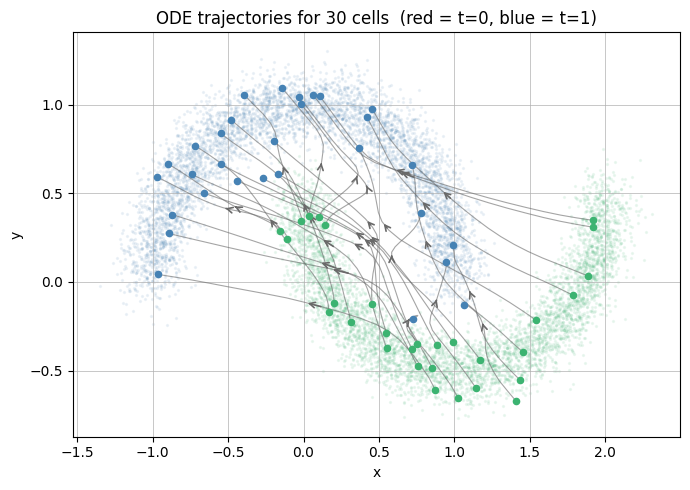

In [27]:
# Same cells as Section 7
src_small = src_t[idx]

model.vf.eval()
with torch.no_grad():
    traj = model.predict_trajectory(src_small, n_steps=20)

traj_np = traj.numpy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(src_np[:, 0], src_np[:, 1], s=2, alpha=0.08, color="mediumseagreen")
ax.scatter(tgt_np[:, 0], tgt_np[:, 1], s=2, alpha=0.08, color="steelblue")

mid = traj_np.shape[0] // 2  # midpoint index for arrowhead

for i in range(n_show):
    ax.plot(traj_np[:, i, 0], traj_np[:, i, 1], lw=0.8, alpha=0.6, color="dimgray")
    # Arrowhead at midpoint to show direction of travel
    ax.annotate(
        "",
        xy=(traj_np[mid + 1, i, 0], traj_np[mid + 1, i, 1]),
        xytext=(traj_np[mid, i, 0], traj_np[mid, i, 1]),
        arrowprops={"arrowstyle": "->", "color": "dimgray", "lw": 1.2},
    )
    ax.scatter(traj_np[0, i, 0], traj_np[0, i, 1], s=20, color="mediumseagreen", zorder=5)
    ax.scatter(traj_np[-1, i, 0], traj_np[-1, i, 1], s=20, color="steelblue", zorder=5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"ODE trajectories for {n_show} cells  (red = t=0, blue = t=1)")
ax.grid(linewidth=0.5)
plt.tight_layout()
plt.show()

### What's next?

| Tutorial | What it introduces |
|---|---|
| [`300_Toy_Datasets`](../examples/data/300_toy_datasets.ipynb) | Different synthetic data which can be generated |
| [`100_DataManager`](../examples/data/100_datamanager.ipynb) | How to configure the DataManager |
| [`110_unconditional_fm_pbmc.ipynb`](110_unconditional_fm_pbmc.ipynb) | Flow Matching which transports Gaussian noise to PBMC cells |
| [`200_conditional_fm_synthetic.ipynb`](200_conditional_fm_synthetic.ipynb) | Flow Matching which tranports to different targets based on conditions |